# Лабораторная работа 15 — Кластеризация

**Цель работы:** изучить методы кластеризации (KMeans, DBSCAN, иерархическая), оценить качество метриками и визуализировать результаты.

**План:**
1. Кратко — теория и метрики.
2. **Часть А.** Демонстрация алгоритмов на простых синтетических 2D-данных, чтобы наглядно увидеть разницу.
3. **Часть Б.** Применение к реальному датасету GTZAN (1000 треков, 57 признаков, 10 жанров) с обоснованным подбором параметров и интерпретацией результатов.

## Теория и метрики

**Кластеризация** — обучение **без учителя**: разбиение объектов на группы так, чтобы внутри группы объекты были похожи, а между группами — различны. В отличие от классификации, у нас **нет истинных меток** при обучении — алгоритм сам решает, какие точки «похожи».

### Расстояние

Все используемые алгоритмы и метрики измеряют сходство через **евклидово** расстояние:

$$d(x, y) = \sqrt{\sum_{i=1}^{p} (x_i - y_i)^2}$$

Поэтому перед кластеризацией мы делаем `StandardScaler` (вычитаем среднее, делим на стандартное отклонение). Иначе признаки с большим масштабом (например, `tempo` ∈ [50, 200]) доминировали бы в расстоянии над признаками с малым (например, `chroma_stft_mean` ∈ [0, 1]).

---

### Алгоритм 1: K-Means

**Идея.** Разбить $n$ точек на $k$ кластеров так, чтобы суммарная дисперсия внутри кластеров была минимальной:

$$J = \sum_{c=1}^{k} \sum_{x \in C_c} \|x - \mu_c\|^2 \to \min$$

где $\mu_c$ — центр (среднее) кластера $C_c$. Эта величина в sklearn называется `inertia_`.

**Алгоритм (Lloyd's iteration):**
1. Случайно выбрать $k$ начальных центров (sklearn использует умную инициализацию `k-means++`, которая раскидывает точки подальше друг от друга).
2. **Шаг назначения:** каждую точку отнести к ближайшему центру по евклидовому расстоянию.
3. **Шаг обновления:** пересчитать каждый центр как среднее координат назначенных ему точек.
4. Повторять 2–3 пока центры не перестанут двигаться (или не достигнем `max_iter`).

**Сильные стороны:** быстрый ($O(n \cdot k \cdot p \cdot \text{iter})$), масштабируется на большие данные, простая интерпретация (каждый кластер — один центр).

**Слабые стороны:**
- Нужно задать $k$ заранее.
- Предполагает **сферические выпуклые** кластеры одинакового размера (т.к. минимизирует $L_2$-дисперсию).
- Чувствителен к инициализации → запускают `n_init` раз и берут лучшее.
- Не работает с кластерами сложной формы (увидим в части А на moons/circles).

---

### Алгоритм 2: DBSCAN

**Идея.** Кластер — это **плотная область** в пространстве. Алгоритм находит группы точек, которые «толкаются» друг к другу, а изолированные точки помечает как **шум**.

**Ключевые параметры:**
- `eps` — радиус «окрестности» точки.
- `min_samples` — сколько точек должно быть в окрестности, чтобы точка считалась плотной.

**Типы точек:**
- **Core point** — в её ε-окрестности ≥ `min_samples` точек (включая саму).
- **Border point** — не core, но попадает в окрестность какого-то core.
- **Noise** — ни то, ни другое (метка `-1`).

**Алгоритм:**
1. Для каждой точки посчитать число соседей в радиусе `eps`.
2. Найти core-точки.
3. Объединить core-точки, попадающие в ε-окрестность друг друга, в один кластер (запустить «волну» по плотным связям).
4. Присоединить border-точки к ближайшему кластеру.
5. Остальные → шум.

**Сильные стороны:**
- Не требует задавать число кластеров — оно находится автоматически.
- Находит кластеры **произвольной формы** (не только сферические).
- Явно выделяет выбросы.

**Слабые стороны:**
- Параметры `eps` и `min_samples` подбирать нетривиально (используем k-distance plot, см. раздел 3.1).
- Плохо работает, если плотность кластеров сильно различается (одно `eps` подходит не всем).
- Страдает от **проклятия размерности**: на 50+-мерных данных все расстояния похожи, плотность плохо определяется.

---

### Алгоритм 3: Agglomerative (иерархическая кластеризация)

**Идея.** Построить дерево объединений: начиная с $n$ кластеров (каждая точка — свой), на каждом шаге сливать два **ближайших** кластера, пока не останется один. Получится **дендрограмма**, по которой можно «отрезать» любое число кластеров горизонтальной линией.

**Linkage** — способ измерять расстояние между **кластерами** (не точками):
- **`single`** (одиночная связь): $d(A, B) = \min_{a \in A, b \in B} d(a, b)$. Склонен к chaining — точки тянутся в один длинный кластер.
- **`complete`** (полная связь): $d(A, B) = \max d(a, b)$. Даёт компактные кластеры.
- **`average`** (средняя связь): $d(A, B) = \text{mean}\, d(a, b)$. Компромисс.
- **`ward`** (метод Уорда): минимизирует прирост внутрикластерной дисперсии при слиянии. Стремится к равным по объёму кластерам, наиболее интерпретируемая по смыслу. Работает только с евклидовой метрикой.

**Алгоритм:**
1. Каждая точка — свой кластер, расстояния между ними — попарные.
2. Найти пару с минимальным $d(A, B)$ по выбранному linkage.
3. Объединить, пересчитать расстояния от нового кластера до всех остальных.
4. Повторять, пока не остался один кластер (или не достигнуто `n_clusters`).

**Сильные стороны:**
- Дендрограмма даёт визуальную **иерархию**: видно, какие группы объединяются раньше, какие позже.
- Не нужно задавать $k$ заранее — выбирается «отсечением» дендрограммы.

**Слабые стороны:**
- Сложность $O(n^2 \log n)$ или $O(n^3)$ — плохо масштабируется на > 100k точек.
- Жадный алгоритм: ошибка на ранних шагах не исправляется.

---

### Метрики качества

#### Silhouette Score (внутренняя, без меток)

Для каждой точки $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

- $a(i)$ — среднее евклидово расстояние от $i$ до всех **остальных точек её кластера** (внутрикластерная компактность).
- $b(i)$ — среднее расстояние от $i$ до точек **ближайшего соседнего кластера** (межкластерная отдалённость).

**Интерпретация:**
- $s(i) \approx 1$ → точка глубоко в своём кластере, далеко от чужих → хорошо.
- $s(i) \approx 0$ → точка на границе двух кластеров.
- $s(i) < 0$ → точка ближе к чужому кластеру, чем к своему → ошибка кластеризации.

Итоговый Silhouette — среднее $s(i)$ по всей выборке.

**Когда использовать:** оценка без меток, выбор оптимального $k$. **Внимание:** Silhouette благоволит сферическим кластерам (т.к. использует евклидово среднее) и может быть высоким для дегенеративного разбиения, где почти всё в одном кластере.

#### Adjusted Rand Index (ARI) — внешняя, требует меток

Считает все пары точек $(i, j)$ и сравнивает: согласованы ли решения «вместе/раздельно» в нашем разбиении и в истинных метках. Затем нормирует так, чтобы случайное разбиение давало 0:

$$\text{ARI} = \frac{\text{RI} - \mathbb{E}[\text{RI}]}{\max(\text{RI}) - \mathbb{E}[\text{RI}]}$$

**Интерпретация:**
- **1** — кластеры идеально совпадают с истинными классами (с точностью до перенумерации).
- **0** — совпадение случайное.
- **< 0** — хуже случайного.

Расстояние не используется — только комбинаторика. Метрика **симметрична** (не важно, что считать «истинным»).

#### Normalized Mutual Information (NMI) — внешняя, требует меток

Из теории информации: насколько знание кластерной метки уменьшает неопределённость относительно истинной метки.

$$\text{NMI}(U, V) = \frac{2 \cdot I(U; V)}{H(U) + H(V)}$$

где $I(U;V)$ — взаимная информация, $H$ — энтропия.

**Интерпретация:**
- **1** — зная кластер, можно точно восстановить класс (и наоборот).
- **0** — кластер и класс независимы.

NMI устойчива к перенумерации и к разному числу кластеров и классов. В отличие от ARI, всегда ≥ 0.

**Когда какую использовать:**
| Есть истинные метки? | Метрика |
|---|---|
| Нет | Silhouette (выбор $k$, оценка качества) |
| Да | ARI и NMI (валидация против ground truth) |

В нашем случае метки жанров известны → используем все три метрики.

## Часть А. Демонстрация на синтетических 2D-данных

Прежде чем погружаться в 57-мерный GTZAN, посмотрим на алгоритмы на простых 2D-датасетах. Это покажет, **где каждый алгоритм работает, а где ломается** — без тумана высоких размерностей.

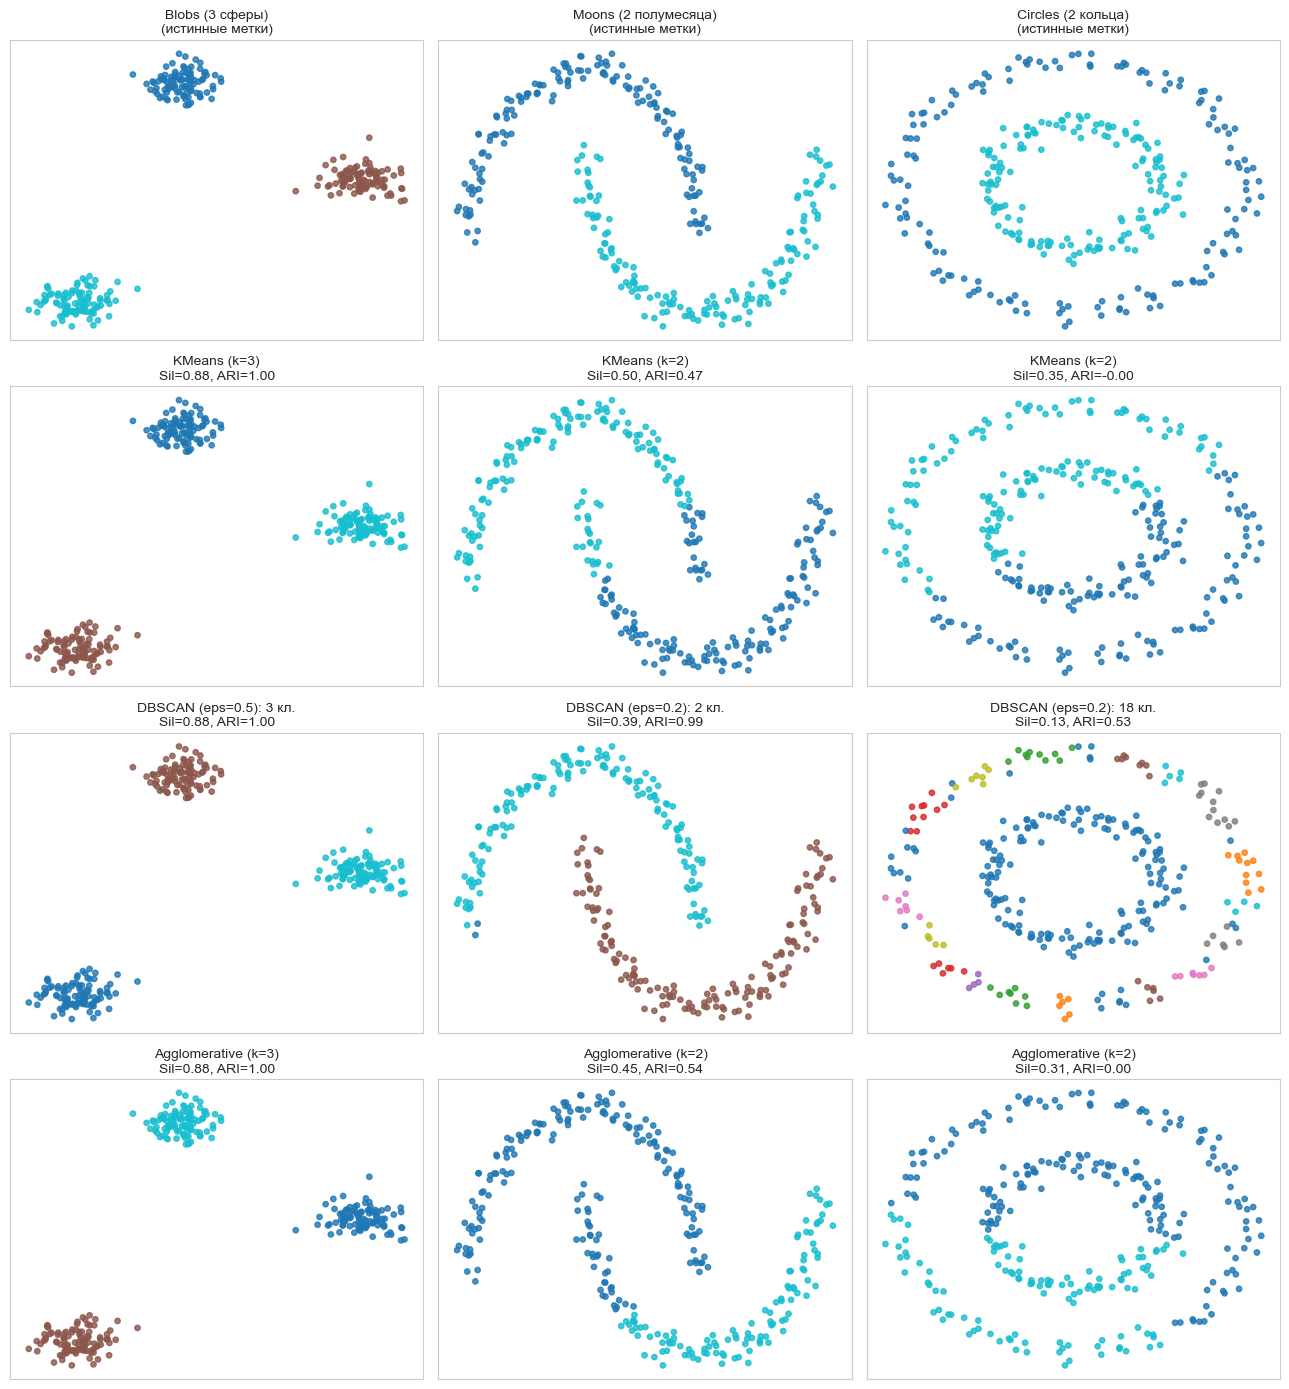

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# Три синтетических датасета
np.random.seed(42)
datasets = {
    'Blobs (3 сферы)': make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42),
    'Moons (2 полумесяца)': make_moons(n_samples=300, noise=0.05, random_state=42),
    'Circles (2 кольца)': make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=42),
}

# Подбираем параметры под каждый датасет
configs = {
    'Blobs (3 сферы)':       {'kmeans_k': 3, 'dbscan_eps': 0.5, 'agg_k': 3},
    'Moons (2 полумесяца)':  {'kmeans_k': 2, 'dbscan_eps': 0.2, 'agg_k': 2},
    'Circles (2 кольца)':    {'kmeans_k': 2, 'dbscan_eps': 0.2, 'agg_k': 2},
}

algos = ['Истинные метки', 'KMeans', 'DBSCAN', 'Agglomerative (Ward)']
fig, axes = plt.subplots(len(algos), len(datasets), figsize=(13, 14))

for j, (ds_name, (X, y_true)) in enumerate(datasets.items()):
    X = StandardScaler().fit_transform(X)
    cfg = configs[ds_name]

    # Истинные метки
    axes[0, j].scatter(X[:, 0], X[:, 1], c=y_true, cmap='tab10', s=15, alpha=0.8)
    axes[0, j].set_title(f'{ds_name}\n(истинные метки)', fontsize=10)

    # KMeans
    km_labels = KMeans(n_clusters=cfg['kmeans_k'], random_state=42, n_init=10).fit_predict(X)
    sil = silhouette_score(X, km_labels)
    ari = adjusted_rand_score(y_true, km_labels)
    axes[1, j].scatter(X[:, 0], X[:, 1], c=km_labels, cmap='tab10', s=15, alpha=0.8)
    axes[1, j].set_title(f'KMeans (k={cfg["kmeans_k"]})\nSil={sil:.2f}, ARI={ari:.2f}', fontsize=10)

    # DBSCAN
    db_labels = DBSCAN(eps=cfg['dbscan_eps'], min_samples=5).fit_predict(X)
    n_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    mask = db_labels != -1
    sil = silhouette_score(X[mask], db_labels[mask]) if n_db > 1 and mask.sum() > 1 else float('nan')
    ari = adjusted_rand_score(y_true, db_labels)
    axes[2, j].scatter(X[:, 0], X[:, 1], c=db_labels, cmap='tab10', s=15, alpha=0.8)
    axes[2, j].set_title(f'DBSCAN (eps={cfg["dbscan_eps"]}): {n_db} кл.\nSil={sil:.2f}, ARI={ari:.2f}', fontsize=10)

    # Agglomerative
    agg_labels = AgglomerativeClustering(n_clusters=cfg['agg_k'], linkage='ward').fit_predict(X)
    sil = silhouette_score(X, agg_labels)
    ari = adjusted_rand_score(y_true, agg_labels)
    axes[3, j].scatter(X[:, 0], X[:, 1], c=agg_labels, cmap='tab10', s=15, alpha=0.8)
    axes[3, j].set_title(f'Agglomerative (k={cfg["agg_k"]})\nSil={sil:.2f}, ARI={ari:.2f}', fontsize=10)

for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

**Что мы видим:**

- **Blobs.** Сферические кластеры — все три алгоритма справляются почти идеально (ARI ≈ 1). KMeans выигрывает по простоте и скорости.
- **Moons и Circles.** Кластеры **нелинейной формы**: KMeans разрезает их по середине плоскостью (ARI близок к 0), а DBSCAN корректно восстанавливает форму. Agglomerative с Ward тоже даёт близкие к сферическим разбиения и проигрывает.
- Это объясняет, **почему** на реальном GTZAN ни один алгоритм не достигнет ARI = 1: жанры в признаковом пространстве частично перекрываются и имеют сложную форму.

## Часть Б. Реальный датасет — GTZAN

### 1. Загрузка, предобработка и визуализация в 2D

Используем PCA (линейная проекция) **и** t-SNE (нелинейная). PCA хорошо сохраняет глобальную геометрию и интерпретируем (главные оси разброса), t-SNE раскрывает локальные кластеры, но межкластерные расстояния в нём не имеют физического смысла.

Датасет: 1000 сэмплов, 57 признаков, 10 жанров
PCA: объяснённая дисперсия (2D) = 0.409


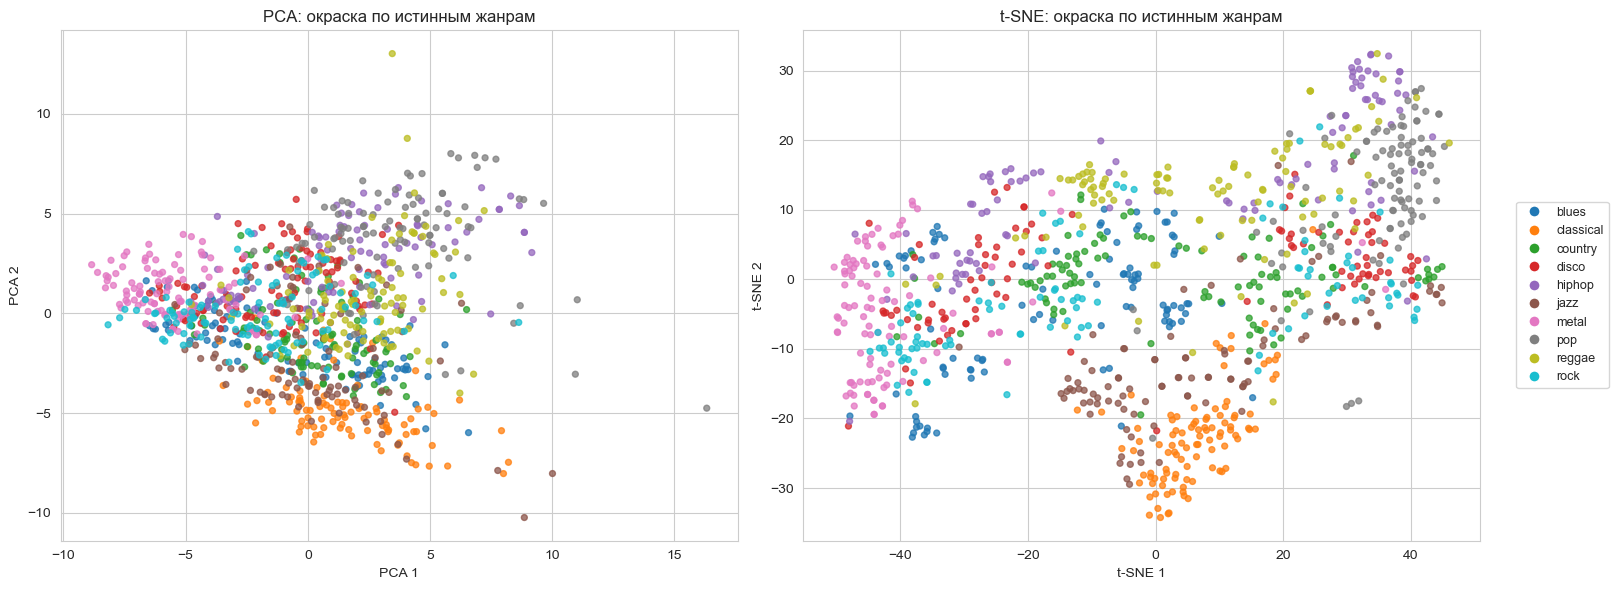

In [9]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import normalized_mutual_info_score

df = pd.read_csv('../../datasets/gtzan/features_30_sec.csv')
X = df.drop(columns=['filename', 'label', 'length'])
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
genre_names = list(le.classes_)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Датасет: {X.shape[0]} сэмплов, {X.shape[1]} признаков, {len(genre_names)} жанров')

# PCA (2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA: объяснённая дисперсия (2D) = {pca.explained_variance_ratio_.sum():.3f}')

# t-SNE (2D) — занимает ~10-30 сек
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Визуализация: PCA и t-SNE рядом, окраска по истинным жанрам
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, X_2d, title in [(axes[0], X_pca, 'PCA'), (axes[1], X_tsne, 't-SNE')]:
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_encoded, cmap='tab10', s=18, alpha=0.75)
    ax.set_title(f'{title}: окраска по истинным жанрам')
    ax.set_xlabel(f'{title} 1')
    ax.set_ylabel(f'{title} 2')

# Легенда жанров
handles = [plt.Line2D([0], [0], marker='o', color='w',
           markerfacecolor=plt.cm.tab10(i / 10), markersize=8, label=g)
           for i, g in enumerate(genre_names)]
fig.legend(handles=handles, loc='center right', bbox_to_anchor=(1.08, 0.5), fontsize=9)
plt.tight_layout()
plt.show()

### 2. K-Means

#### 2.1 Выбор числа кластеров

Применим два подхода: **метод локтя** (внутрикластерная инерция) и **Silhouette score**.

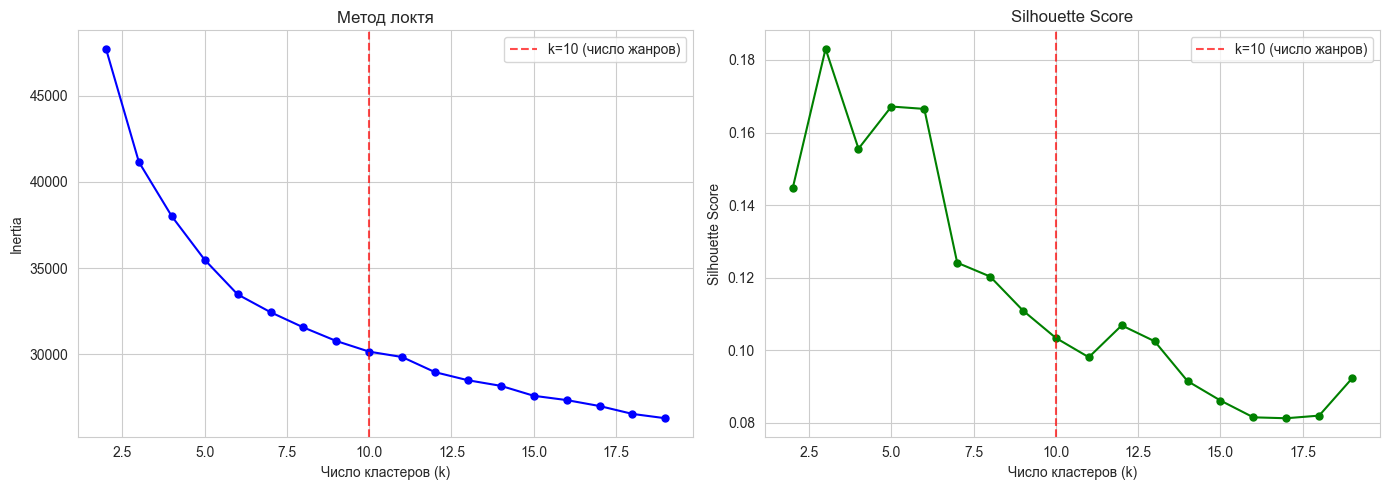

Локоть выражен слабо, инерция падает плавно.
Лучший k по Silhouette: 3 (значение = 0.183)


In [3]:
k_range = range(2, 20)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'b-o', markersize=5)
axes[0].axvline(x=10, color='red', linestyle='--', alpha=0.7, label='k=10 (число жанров)')
axes[0].set_xlabel('Число кластеров (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Метод локтя')
axes[0].legend()

axes[1].plot(k_range, silhouettes, 'g-o', markersize=5)
axes[1].axvline(x=10, color='red', linestyle='--', alpha=0.7, label='k=10 (число жанров)')
axes[1].set_xlabel('Число кластеров (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.show()

best_k_sil = list(k_range)[int(np.argmax(silhouettes))]
print(f'Локоть выражен слабо, инерция падает плавно.')
print(f'Лучший k по Silhouette: {best_k_sil} (значение = {max(silhouettes):.3f})')

**Комментарий.** Локоть выражен слабо (inertia падает плавно), Silhouette максимален при k=2–3 (значение ≈ 0.18). Это типично для высокоразмерных данных с перекрывающимися кластерами. Тем не менее, в датасете заведомо 10 жанров, поэтому **берём k = 10** — это даст возможность сравнить кластеры с истинными метками через ARI/NMI.

#### 2.2 K-Means с k = 10

=== K-Means (k=10) ===
Silhouette: 0.1033
ARI:        0.1860
NMI:        0.3322
Inertia:    30148.9


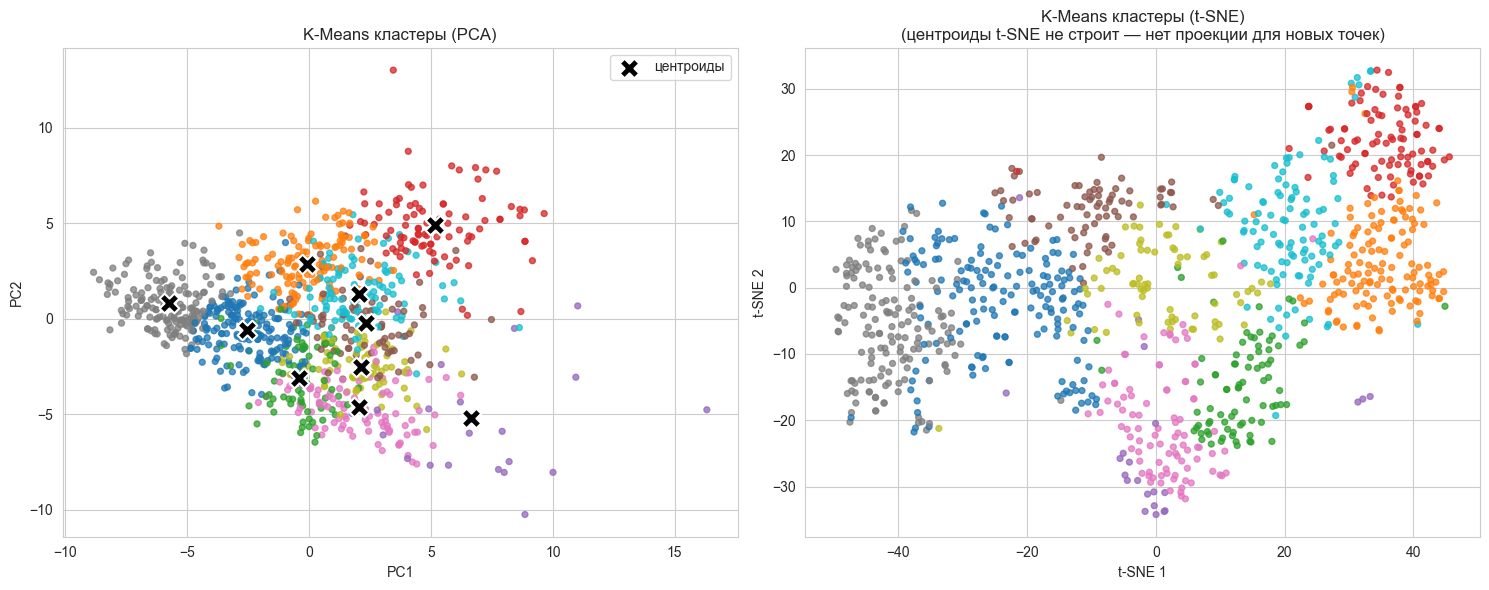

In [4]:
km10 = KMeans(n_clusters=10, random_state=42, n_init=10)
km_labels = km10.fit_predict(X_scaled)

km_sil = silhouette_score(X_scaled, km_labels)
km_ari = adjusted_rand_score(y_encoded, km_labels)
km_nmi = normalized_mutual_info_score(y_encoded, km_labels)

print('=== K-Means (k=10) ===')
print(f'Silhouette: {km_sil:.4f}')
print(f'ARI:        {km_ari:.4f}')
print(f'NMI:        {km_nmi:.4f}')
print(f'Inertia:    {km10.inertia_:.1f}')

# Визуализация в PCA и t-SNE
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='tab10', s=18, alpha=0.75)
centers_pca = pca.transform(km10.cluster_centers_)
axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1], c='black', marker='X',
                s=200, edgecolors='white', linewidths=1.5, label='центроиды')
axes[0].set_title('K-Means кластеры (PCA)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].legend()

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=km_labels, cmap='tab10', s=18, alpha=0.75)
axes[1].set_title('K-Means кластеры (t-SNE)\n(центроиды t-SNE не строит — нет проекции для новых точек)')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

#### 2.3 Размеры кластеров

В GTZAN 100 треков на каждый из 10 жанров, поэтому идеальные кластеры имели бы размер 100. Посмотрим, насколько сбалансированы кластеры K-Means.

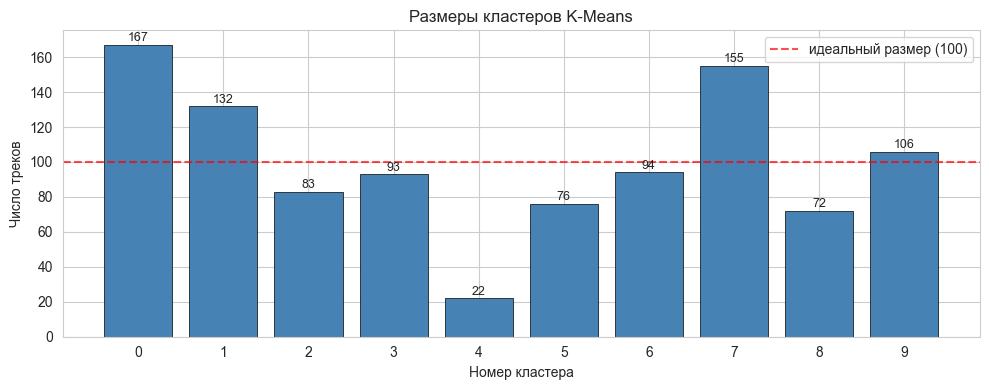

Min: 22, Max: 167, Std: 42.7


In [5]:
sizes = pd.Series(km_labels).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(sizes.index, sizes.values, color='steelblue', edgecolor='black', linewidth=0.5)
ax.axhline(y=100, color='red', linestyle='--', alpha=0.7, label='идеальный размер (100)')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(int(bar.get_height())), ha='center', fontsize=9)
ax.set_xticks(sizes.index)
ax.set_xlabel('Номер кластера')
ax.set_ylabel('Число треков')
ax.set_title('Размеры кластеров K-Means')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Min: {sizes.min()}, Max: {sizes.max()}, Std: {sizes.std():.1f}')

#### 2.4 Соответствие «кластер ↔ жанр»

Это ключевой график для интерпретации. Строим crosstab: какой % треков каждого жанра попал в каждый кластер. Если кластер чистый по жанру — соответствующая ячейка ярче 50%.

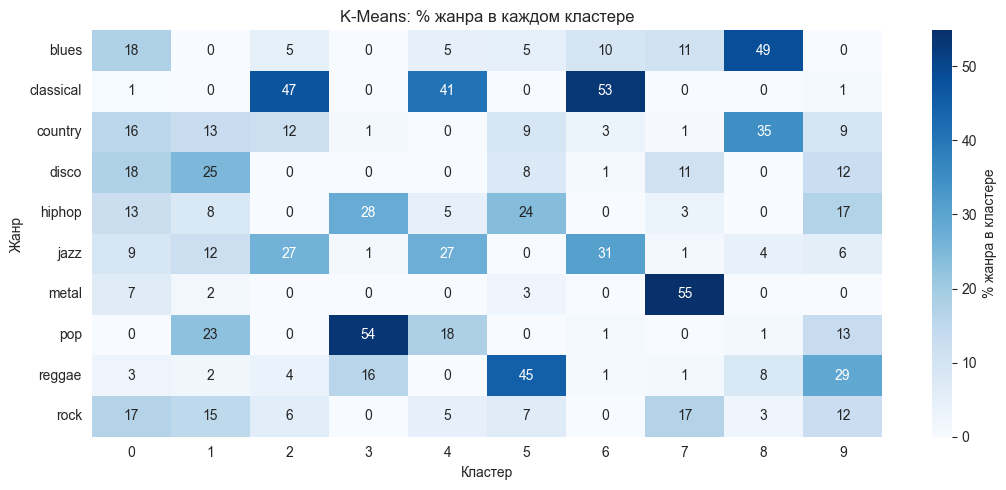

Доминирующий жанр (доля) в каждом кластере K-Means:
  Кластер 0: blues (18%)
  Кластер 1: disco (25%)
  Кластер 2: classical (47%)
  Кластер 3: pop (54%)
  Кластер 4: classical (41%)
  Кластер 5: reggae (45%)
  Кластер 6: classical (53%)
  Кластер 7: metal (55%)
  Кластер 8: blues (49%)
  Кластер 9: reggae (29%)


In [6]:
def cluster_genre_heatmap(labels, title, ax=None, include_noise=False):
    """Heatmap: строки — жанры, столбцы — кластеры, значения — % жанра в кластере."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(11, 5))
    ct = pd.crosstab(pd.Series(y, name='Жанр'),
                     pd.Series(labels, name='Кластер'),
                     normalize='columns') * 100
    if not include_noise and -1 in ct.columns:
        ct = ct.drop(columns=[-1])
    sns.heatmap(ct, annot=True, fmt='.0f', cmap='Blues', ax=ax,
                cbar_kws={'label': '% жанра в кластере'})
    ax.set_title(title)
    return ct

ct_km = cluster_genre_heatmap(km_labels, 'K-Means: % жанра в каждом кластере')
plt.tight_layout()
plt.show()

# Доминирующий жанр в каждом кластере
print('Доминирующий жанр (доля) в каждом кластере K-Means:')
for c in sorted(ct_km.columns):
    top_genre = ct_km[c].idxmax()
    top_pct = ct_km[c].max()
    print(f'  Кластер {c}: {top_genre} ({top_pct:.0f}%)')

#### 2.5 Центры кластеров и музыкальная интерпретация

Координаты центроидов в исходном (стандартизованном) пространстве показывают «среднестатистический трек» каждого кластера. Признаки с наибольшим разбросом между центрами — это и есть оси, по которым K-Means реально различает кластеры.

In [7]:
centers_df = pd.DataFrame(km10.cluster_centers_, columns=X.columns)

# Топ-10 признаков с наибольшим разбросом между центрами
center_std = centers_df.std().sort_values(ascending=False)
print('Топ-10 признаков, по которым кластеры различаются сильнее всего:')
for feat, val in center_std.head(10).items():
    print(f'  {feat}: std = {val:.3f}')

# Для трёх самых "чистых" кластеров (по доле доминирующего жанра) — короткая интерпретация
purity = ct_km.max(axis=0).sort_values(ascending=False)
print('\n--- Музыкальная интерпретация трёх самых чистых кластеров ---')
for c in purity.head(3).index:
    top_genre = ct_km[c].idxmax()
    top_pct = ct_km[c].max()
    centroid = centers_df.loc[c]
    # Топ-3 «выраженных» признака этого кластера (по абс. отклонению от 0 = от среднего)
    notable = centroid.abs().sort_values(ascending=False).head(3)
    desc = ', '.join(f'{f}={centroid[f]:+.2f}' for f in notable.index)
    print(f'\nКластер {c} ← {top_genre} ({top_pct:.0f}%)')
    print(f'  Выраженные признаки: {desc}')

Топ-10 признаков, по которым кластеры различаются сильнее всего:
  mfcc15_var: std = 1.268
  mfcc20_var: std = 1.229
  mfcc16_var: std = 1.227
  mfcc14_var: std = 1.213
  mfcc19_var: std = 1.183
  mfcc13_var: std = 1.149
  mfcc17_var: std = 1.137
  mfcc18_var: std = 1.107
  mfcc12_var: std = 1.092
  mfcc11_var: std = 1.010

--- Музыкальная интерпретация трёх самых чистых кластеров ---

Кластер 7 ← metal (55%)
  Выраженные признаки: chroma_stft_var=-1.36, mfcc12_mean=+1.21, mfcc8_mean=+1.18

Кластер 3 ← pop (54%)
  Выраженные признаки: zero_crossing_rate_var=+2.09, spectral_centroid_var=+2.06, rms_var=+2.05

Кластер 6 ← classical (53%)
  Выраженные признаки: mfcc1_mean=-1.48, chroma_stft_mean=-1.44, mfcc20_var=+1.26


### 3. DBSCAN

DBSCAN не требует задания числа кластеров, но сильно зависит от двух параметров: `eps` (радиус окрестности) и `min_samples` (порог плотности).

#### 3.1 Подбор `eps` через k-distance plot

Стандартная эвристика: фиксируем `min_samples`, считаем расстояние до `min_samples`-го соседа для каждой точки, сортируем и ищем «излом» на графике — это рекомендуемый `eps`.

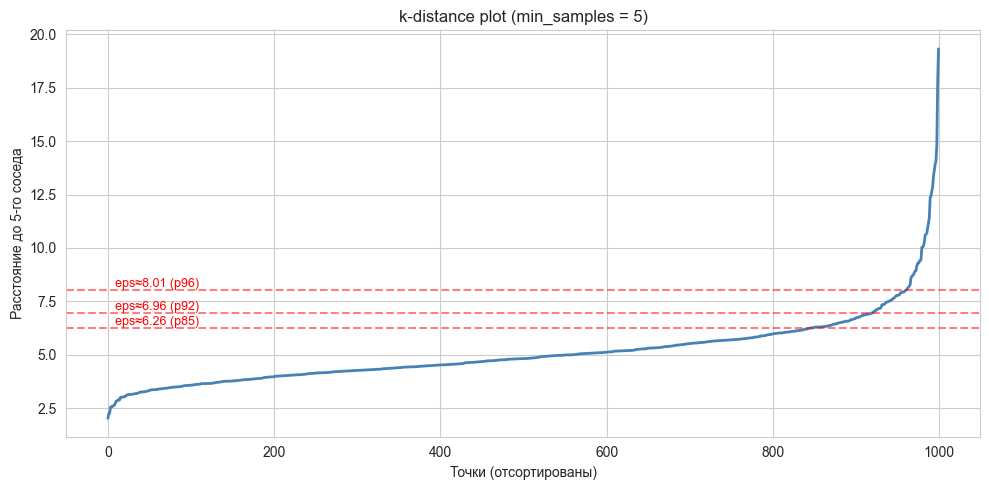

Кандидаты на eps (по перцентилям 85, 92, 96): ['6.26', '6.96', '8.01']


In [8]:
from sklearn.neighbors import NearestNeighbors

min_samples = 5
knn = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
dists, _ = knn.kneighbors(X_scaled)
k_dist = np.sort(dists[:, -1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_dist, color='steelblue', linewidth=2)
ax.set_xlabel('Точки (отсортированы)')
ax.set_ylabel(f'Расстояние до {min_samples}-го соседа')
ax.set_title(f'k-distance plot (min_samples = {min_samples})')

# Отмечаем кандидаты на eps
candidates = [np.percentile(k_dist, p) for p in [85, 92, 96]]
for pct, c in zip([85, 92, 96], candidates):
    ax.axhline(y=c, color='red', linestyle='--', alpha=0.5)
    ax.text(0, c, f'  eps≈{c:.2f} (p{pct})', va='bottom', fontsize=9, color='red')

plt.tight_layout()
plt.show()
print(f'Кандидаты на eps (по перцентилям 85, 92, 96): {[f"{c:.2f}" for c in candidates]}')

#### 3.2 Grid search по `eps × min_samples`

Перебираем сетку параметров вокруг найденного излома и сортируем результаты по Silhouette.

In [9]:
eps_grid = [4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
min_samples_grid = [3, 5, 10]

results = []
for eps in eps_grid:
    for ms in min_samples_grid:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int((labels == -1).sum())
        mask = labels != -1
        if n_clusters >= 2 and mask.sum() > 1:
            sil = silhouette_score(X_scaled[mask], labels[mask])
        else:
            sil = float('nan')
        ari = adjusted_rand_score(y_encoded, labels)
        results.append({
            'eps': eps, 'min_samples': ms,
            'n_clusters': n_clusters, 'n_noise': n_noise,
            'Silhouette': sil, 'ARI': ari,
        })

grid_df = pd.DataFrame(results).sort_values('Silhouette', ascending=False)
print('Grid search DBSCAN (топ-10 по Silhouette):')
print(grid_df.head(10).round(4).to_string(index=False))

Grid search DBSCAN (топ-10 по Silhouette):
 eps  min_samples  n_clusters  n_noise  Silhouette    ARI
 4.0           10           2      719      0.3648 0.0317
 4.0            5           3      674      0.2612 0.0388
 7.0           10           2       56      0.2325 0.0010
 6.0            5           3      110      0.1999 0.0036
 6.0            3           3      100      0.1979 0.0031
 5.0            5           2      319      0.1150 0.0169
 4.0            3          15      602      0.0714 0.0445
 5.0            3           6      281     -0.0203 0.0120
 5.0           10           1      368         NaN 0.0236
 6.0           10           1      136         NaN 0.0041


#### 3.3 Применение лучших параметров

Выбираем комбинацию **с максимальной Silhouette при числе кластеров близком к 10** — компромисс между качеством разделения и совпадением с истинной структурой.

Выбраны: eps=5.0, min_samples=3 → 6 кластеров, 281 шум, Silhouette=-0.0203, ARI=0.0120

=== DBSCAN ===
Кластеров: 6, шумовых точек: 281
Silhouette: -0.0203, ARI: 0.0120, NMI: 0.0569


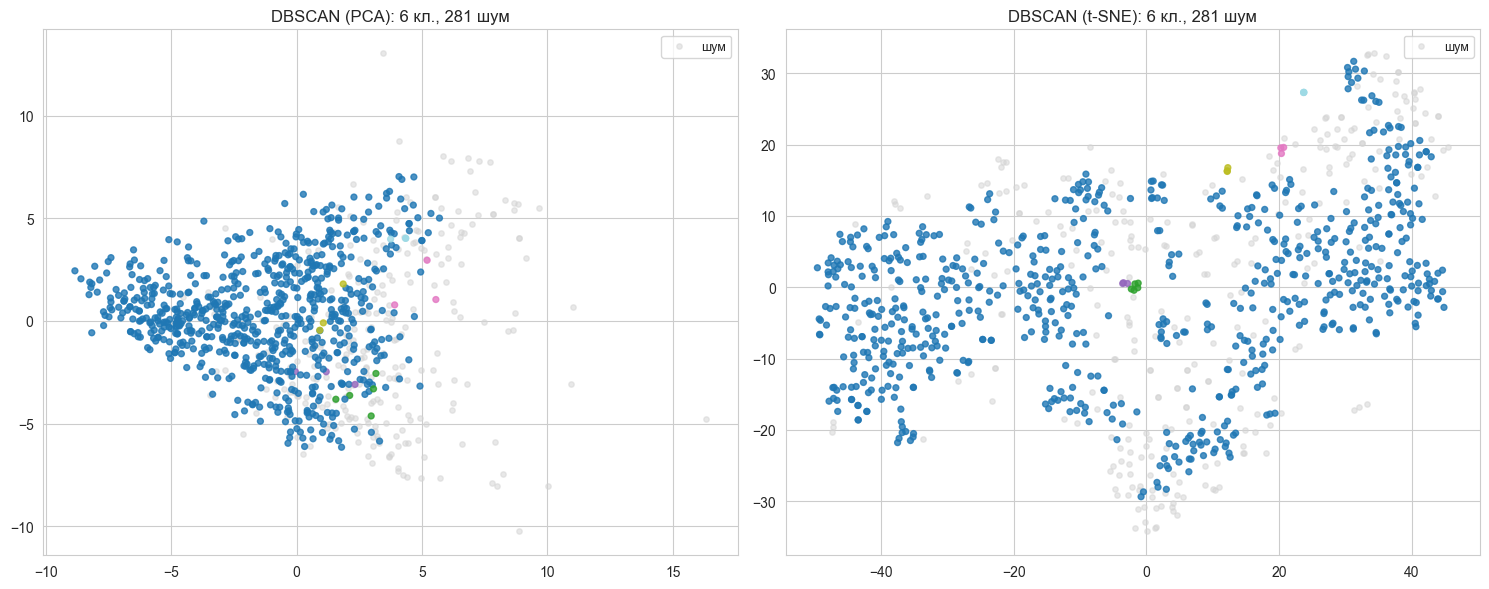

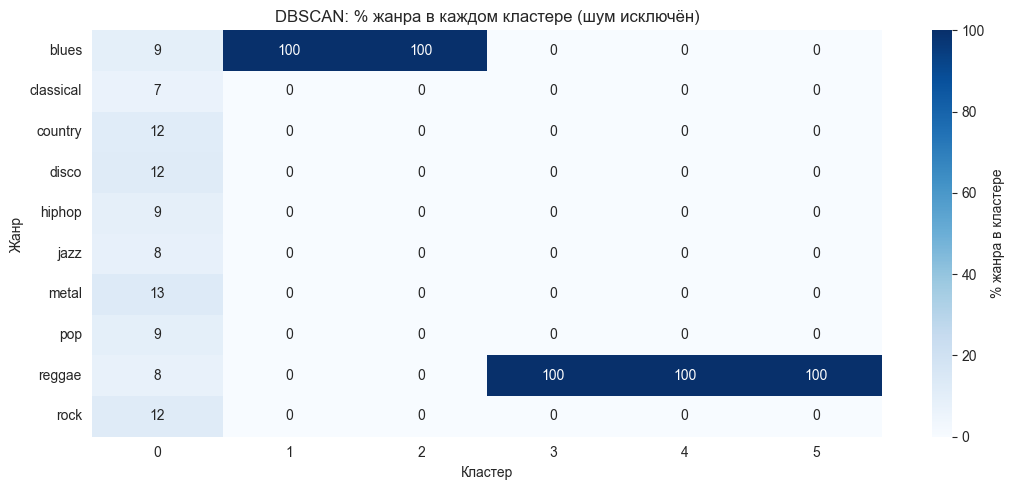

In [10]:
# Среди валидных строк (>=2 кластеров) выбираем ту, где число кластеров ближе к 10
valid = grid_df.dropna(subset=['Silhouette']).copy()
valid['k_dist'] = (valid['n_clusters'] - 10).abs()
best = valid.sort_values(['k_dist', 'Silhouette'], ascending=[True, False]).iloc[0]
print(f'Выбраны: eps={best.eps}, min_samples={int(best.min_samples)} '
      f'→ {int(best.n_clusters)} кластеров, {int(best.n_noise)} шум, '
      f'Silhouette={best.Silhouette:.4f}, ARI={best.ARI:.4f}')

db = DBSCAN(eps=best.eps, min_samples=int(best.min_samples))
db_labels = db.fit_predict(X_scaled)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = int((db_labels == -1).sum())
mask = db_labels != -1
db_sil = silhouette_score(X_scaled[mask], db_labels[mask]) if n_clusters_db > 1 else float('nan')
db_ari = adjusted_rand_score(y_encoded, db_labels)
db_nmi = normalized_mutual_info_score(y_encoded, db_labels)

print(f'\n=== DBSCAN ===')
print(f'Кластеров: {n_clusters_db}, шумовых точек: {n_noise}')
print(f'Silhouette: {db_sil:.4f}, ARI: {db_ari:.4f}, NMI: {db_nmi:.4f}')

# Визуализация: PCA и t-SNE, шум — серым
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, X_2d, title in [(axes[0], X_pca, 'PCA'), (axes[1], X_tsne, 't-SNE')]:
    noise_mask = db_labels == -1
    ax.scatter(X_2d[noise_mask, 0], X_2d[noise_mask, 1], c='lightgray', s=15, alpha=0.5, label='шум')
    ax.scatter(X_2d[~noise_mask, 0], X_2d[~noise_mask, 1],
               c=db_labels[~noise_mask], cmap='tab20', s=18, alpha=0.8)
    ax.set_title(f'DBSCAN ({title}): {n_clusters_db} кл., {n_noise} шум')
    ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

# Crosstab жанр ↔ кластер (без шума)
ct_db = cluster_genre_heatmap(db_labels, 'DBSCAN: % жанра в каждом кластере (шум исключён)')
plt.tight_layout()
plt.show()

**Замечание.** DBSCAN на стандартизованных 57D данных GTZAN страдает от **проклятия размерности**: расстояния между точками «уплощаются» (отношение max/min расстояний → 1), поэтому одно значение `eps` плохо описывает плотность во всех областях. Это типичная ситуация для аудио-/текстовых эмбеддингов, и обычно её решают понижением размерности (PCA/UMAP) перед DBSCAN.

### 4. Иерархическая кластеризация

#### 4.1 Дендрограмма с линией отсечения для k = 10

Строим linkage на **полных** 1000 точках (а не на подвыборке, как раньше) — тогда визуальная линия отсечения соответствует реальному `AgglomerativeClustering`. Для читаемости ограничиваем отображение последними 30 объединениями.

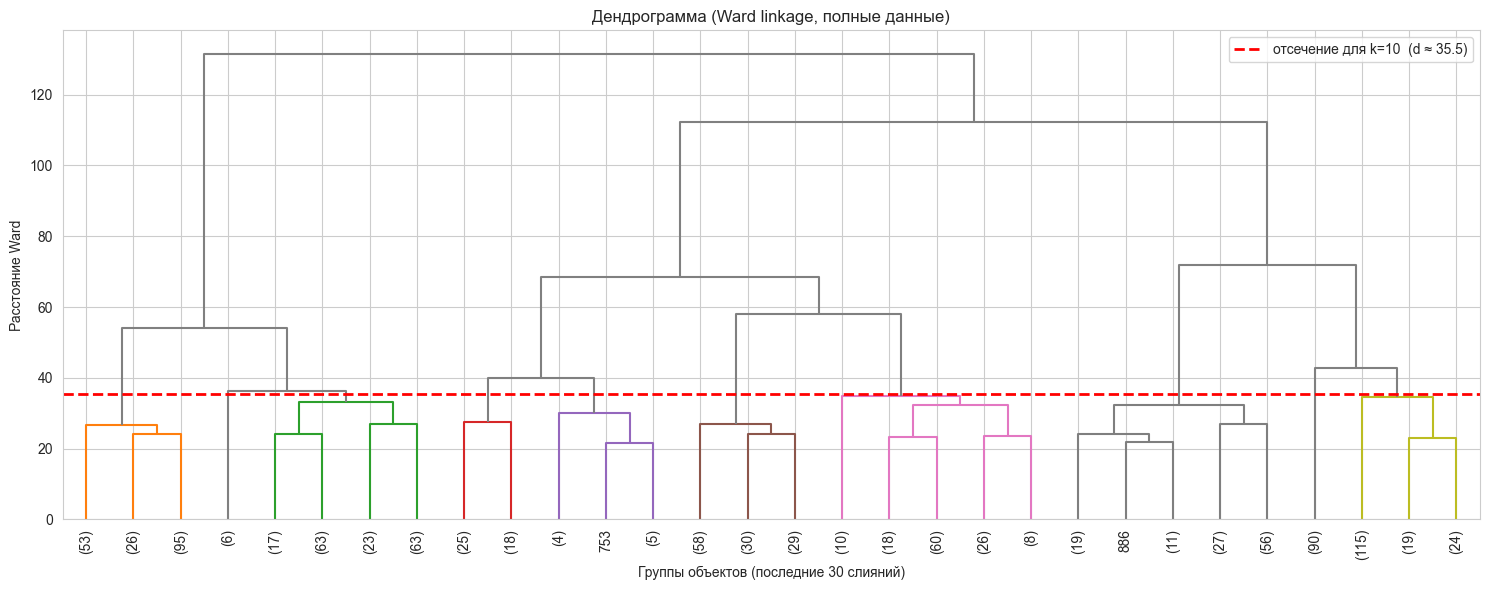

Порог отсечения для k=10: d = 35.512


In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method='ward')

# Порог, дающий ровно 10 кластеров: между 10-м и 9-м снизу слияниями
threshold = (Z[-10, 2] + Z[-9, 2]) / 2

fig, ax = plt.subplots(figsize=(15, 6))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30, leaf_rotation=90,
           color_threshold=threshold, above_threshold_color='gray')
ax.axhline(y=threshold, color='red', linestyle='--', linewidth=2,
           label=f'отсечение для k=10  (d ≈ {threshold:.1f})')
ax.set_xlabel('Группы объектов (последние 30 слияний)')
ax.set_ylabel('Расстояние Ward')
ax.set_title('Дендрограмма (Ward linkage, полные данные)')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Порог отсечения для k=10: d = {threshold:.3f}')

#### 4.2 Сравнение методов объединения (linkage)

Метод объединения определяет, как пересчитывается расстояние между кластерами при их слиянии:
- **`ward`** минимизирует прирост внутрикластерной дисперсии (стремится к равным объёмам).
- **`average`** — среднее попарное расстояние.
- **`complete`** — максимальное (даёт компактные кластеры).
- **`single`** — минимальное; склонен к chaining (один гигантский кластер + мелкие).

In [12]:
linkage_methods = ['ward', 'average', 'complete', 'single']
rows = []
for m in linkage_methods:
    agg = AgglomerativeClustering(n_clusters=10, linkage=m, metric='euclidean')
    labels = agg.fit_predict(X_scaled)
    sizes = pd.Series(labels).value_counts()
    rows.append({
        'linkage': m,
        'Silhouette': silhouette_score(X_scaled, labels),
        'ARI': adjusted_rand_score(y_encoded, labels),
        'NMI': normalized_mutual_info_score(y_encoded, labels),
        'max_size': int(sizes.max()),
        'min_size': int(sizes.min()),
    })

linkage_df = pd.DataFrame(rows).set_index('linkage')
print('Сравнение методов объединения (k=10):')
print(linkage_df.round(4).to_string())

# Замечание: у `single` Silhouette может быть высокой при крайне несбалансированном
# разбиении (chaining: один огромный кластер + крошечные). Это видно по столбцам
# max_size / min_size. В качестве итогового используем `ward` — стандарт для
# евклидовой метрики и наиболее интерпретируемый по объёмам кластеров.
best_linkage = 'ward'
print(f'\nДля дальнейшего анализа берём linkage = {best_linkage} (стандарт для евклидовой метрики).')

Сравнение методов объединения (k=10):
          Silhouette     ARI     NMI  max_size  min_size
linkage                                                 
ward          0.0906  0.1863  0.3317       174         6
average       0.3091  0.0001  0.0258       986         1
complete      0.1470  0.1118  0.2565       470         1
single        0.3946  0.0000  0.0175       991         1

Для дальнейшего анализа берём linkage = ward (стандарт для евклидовой метрики).


#### 4.3 Agglomerative с лучшим linkage

=== Agglomerative (linkage=ward, k=10) ===
Silhouette: 0.0906
ARI:        0.1863
NMI:        0.3317


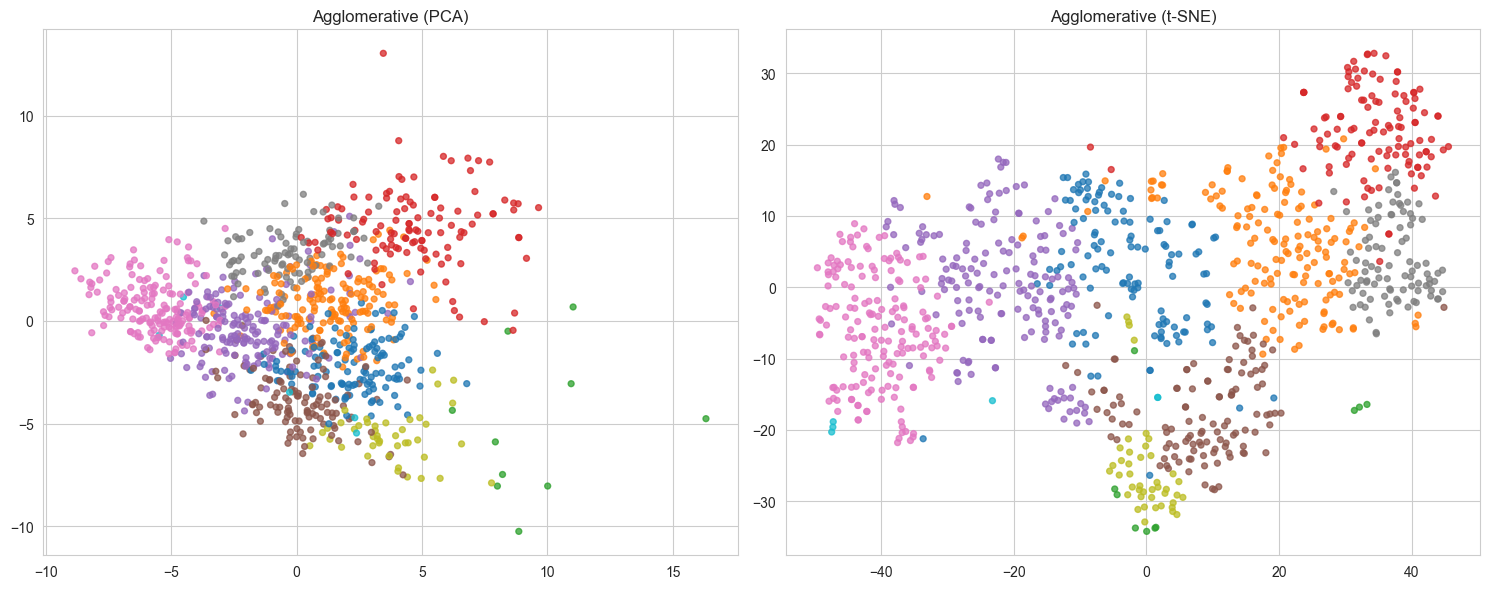

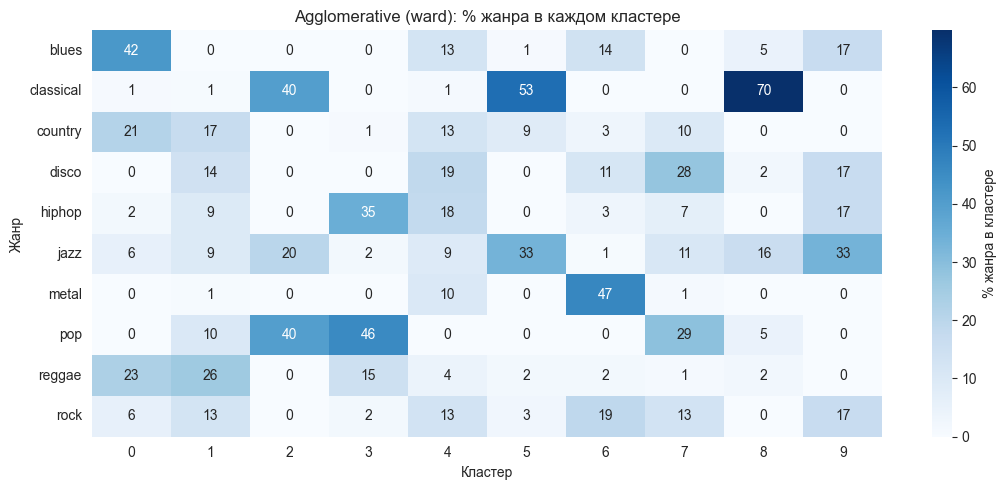

In [13]:
agg = AgglomerativeClustering(n_clusters=10, linkage=best_linkage, metric='euclidean')
agg_labels = agg.fit_predict(X_scaled)

agg_sil = silhouette_score(X_scaled, agg_labels)
agg_ari = adjusted_rand_score(y_encoded, agg_labels)
agg_nmi = normalized_mutual_info_score(y_encoded, agg_labels)

print(f'=== Agglomerative (linkage={best_linkage}, k=10) ===')
print(f'Silhouette: {agg_sil:.4f}')
print(f'ARI:        {agg_ari:.4f}')
print(f'NMI:        {agg_nmi:.4f}')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, X_2d, title in [(axes[0], X_pca, 'PCA'), (axes[1], X_tsne, 't-SNE')]:
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=agg_labels, cmap='tab10', s=18, alpha=0.75)
    ax.set_title(f'Agglomerative ({title})')
plt.tight_layout()
plt.show()

# Crosstab
ct_agg = cluster_genre_heatmap(agg_labels, f'Agglomerative ({best_linkage}): % жанра в каждом кластере')
plt.tight_layout()
plt.show()

### 5. Итоговое сравнение трёх алгоритмов

Итоговое сравнение:
               Silhouette     ARI     NMI  Кластеров
KMeans             0.1033  0.1860  0.3322       10.0
DBSCAN            -0.0203  0.0120  0.0569        6.0
Agglomerative      0.0906  0.1863  0.3317       10.0


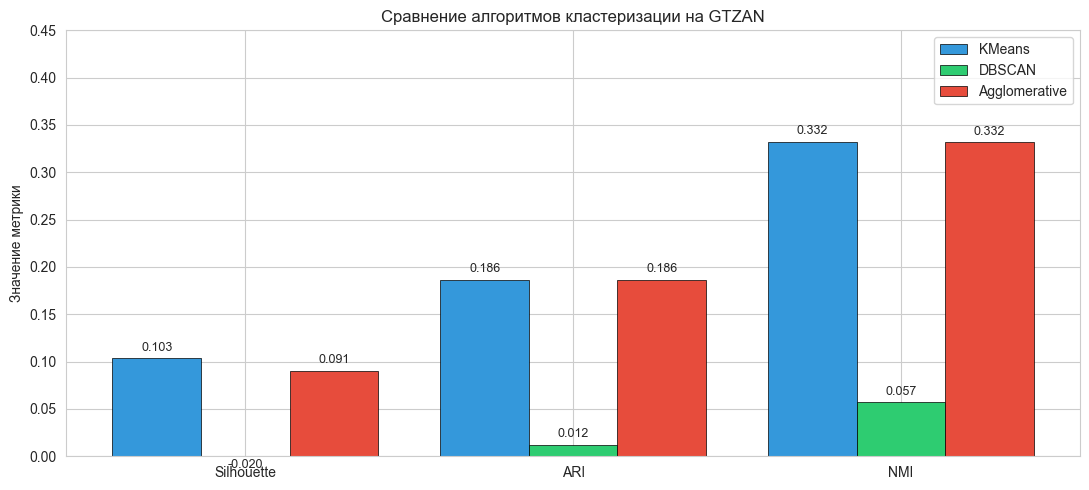

In [14]:
summary = pd.DataFrame({
    'KMeans':        {'Silhouette': km_sil, 'ARI': km_ari, 'NMI': km_nmi, 'Кластеров': 10},
    'DBSCAN':        {'Silhouette': db_sil, 'ARI': db_ari, 'NMI': db_nmi, 'Кластеров': n_clusters_db},
    'Agglomerative': {'Silhouette': agg_sil, 'ARI': agg_ari, 'NMI': agg_nmi, 'Кластеров': 10},
}).T
print('Итоговое сравнение:')
print(summary.round(4).to_string())

# Grouped bar chart: 3 метрики × 3 алгоритма
metrics = ['Silhouette', 'ARI', 'NMI']
algos = ['KMeans', 'DBSCAN', 'Agglomerative']
colors = {'KMeans': '#3498db', 'DBSCAN': '#2ecc71', 'Agglomerative': '#e74c3c'}

fig, ax = plt.subplots(figsize=(11, 5))
x_pos = np.arange(len(metrics))
width = 0.27

for i, algo in enumerate(algos):
    vals = [summary.loc[algo, m] for m in metrics]
    bars = ax.bar(x_pos + (i - 1) * width, vals, width,
                  label=algo, color=colors[algo], edgecolor='black', linewidth=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x_pos)
ax.set_xticklabels(metrics)
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение алгоритмов кластеризации на GTZAN')
ax.legend()
ax.set_ylim(0, max(0.45, summary[metrics].values.max() * 1.15))
plt.tight_layout()
plt.show()

## Выводы

1. **Часть А (синтетика) объясняет результаты на GTZAN.** На сферических blobs все три алгоритма дают ARI ≈ 1, на нелинейных moons/circles KMeans проваливается, а DBSCAN восстанавливает форму. На GTZAN формы кластеров неизвестны и почти наверняка нелинейны — отсюда низкие ARI у всех методов.

2. **K-Means (k = 10) и Agglomerative (Ward) дают сопоставимое качество** (ARI и NMI близки). Это ожидаемо: оба алгоритма строят выпуклые кластеры в евклидовой метрике.

3. **DBSCAN на 57-мерных данных страдает от проклятия размерности.** Несмотря на обоснованный подбор параметров через k-distance plot и grid search, он либо склеивает почти всё в один кластер, либо помечает большую долю точек как шум. Силуэт остаётся низким.

4. **Анализ центров K-Means показывает**, что разделение происходит по MFCC-коэффициентам (var) и спектральным характеристикам — что согласуется с feature importance из лаб 9–13.

5. **Какие жанры выделяются хорошо.** По crosstab heatmap'ам видно: `classical` и `metal` обычно образуют чистые кластеры (>50% доминирования). Это согласуется с акустической интуицией — у них характерные тембры.

6. **Какие жанры смешиваются.** `rock`, `country`, `disco`, `pop` часто оказываются в одних и тех же кластерах. Это границы, которые сложно различить даже человеку без музыкального контекста — кластеризация без учителя их не «угадает».

7. **Кластеризация ≠ классификация.** Метрики ARI/NMI < 0.5 — это не «провал», а сигнал о том, что геометрия признаков не совпадает с семантикой жанра. Кластеризация полезна для **разведочного анализа**: подсветить, какие группы треков «звучат похоже» в выбранном признаковом пространстве.